In [28]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [29]:
# Load the dataset
df = pd.read_csv('../data/raw/IMDB Dataset.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (50000, 2)

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [30]:
# Check column names, data types, missing values
df.info()

# Check for missing values explicitly
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing values per column:
review       0
sentiment    0
dtype: int64


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


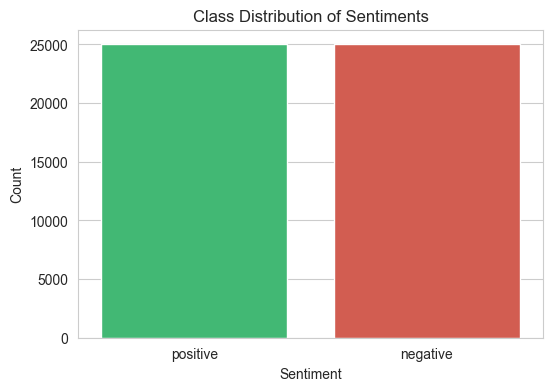

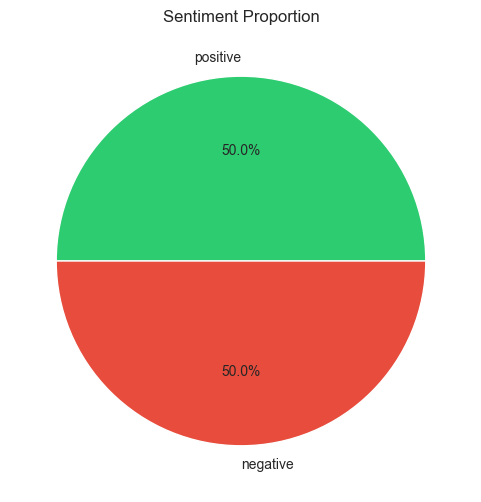

In [31]:
# Check the distribution of sentiments
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

# Visualize
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Also pie chart
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
plt.title('Sentiment Proportion')
plt.show()

In [32]:
# Save class distribution bar plot
plt.figure(1)  # if needed, or refer to the current figure
plt.savefig('../reports/class_distribution.png', dpi=300, bbox_inches='tight')

# Save pie chart separately
plt.figure(2)
plt.savefig('../reports/class_distribution_pie.png', dpi=300, bbox_inches='tight')

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [33]:
# Add a column for review length (number of characters)
df['review_length'] = df['review'].apply(len)

# Add a column for word count
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

# Show summary statistics
print("Review length (characters):")
print(df['review_length'].describe())
print("\nWord count:")
print(df['word_count'].describe())

Review length (characters):
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

Word count:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


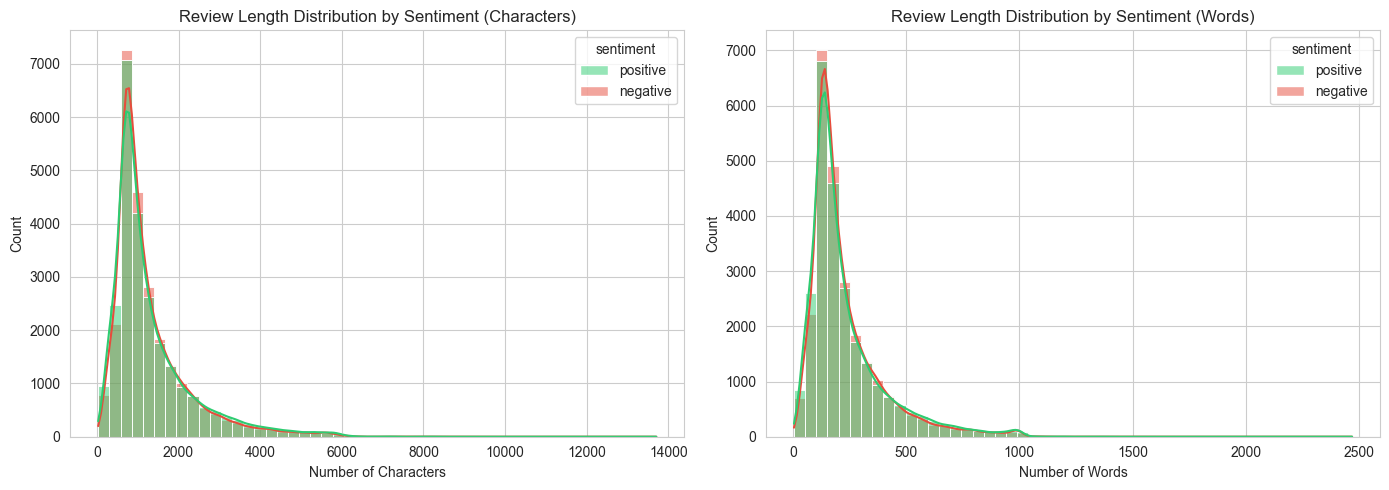

In [34]:
# Plot histograms for review length by sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length
sns.histplot(data=df, x='review_length', hue='sentiment', bins=50, kde=True, ax=axes[0], palette={'positive':'#2ecc71', 'negative':'#e74c3c'})
axes[0].set_title('Review Length Distribution by Sentiment (Characters)')
axes[0].set_xlabel('Number of Characters')

# Word count
sns.histplot(data=df, x='word_count', hue='sentiment', bins=50, kde=True, ax=axes[1], palette={'positive':'#2ecc71', 'negative':'#e74c3c'})
axes[1].set_title('Review Length Distribution by Sentiment (Words)')
axes[1].set_xlabel('Number of Words')

plt.tight_layout()
plt.show()

In [35]:
plt.savefig('../reports/review_length_dist.png', dpi=300, bbox_inches='tight')

<Figure size 1200x600 with 0 Axes>

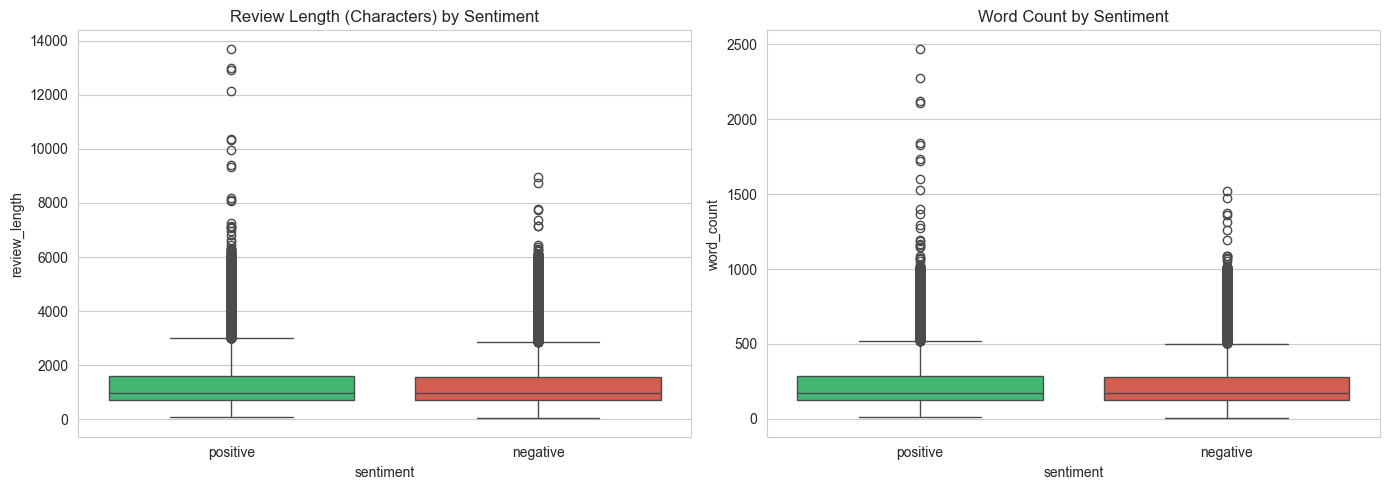

In [36]:
# Boxplots to see outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='sentiment', y='review_length', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Review Length (Characters) by Sentiment')

sns.boxplot(data=df, x='sentiment', y='word_count', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Word Count by Sentiment')

plt.tight_layout()
plt.show()

In [37]:
plt.savefig('../reports/boxplots.png', dpi=300, bbox_inches='tight')

<Figure size 1200x600 with 0 Axes>

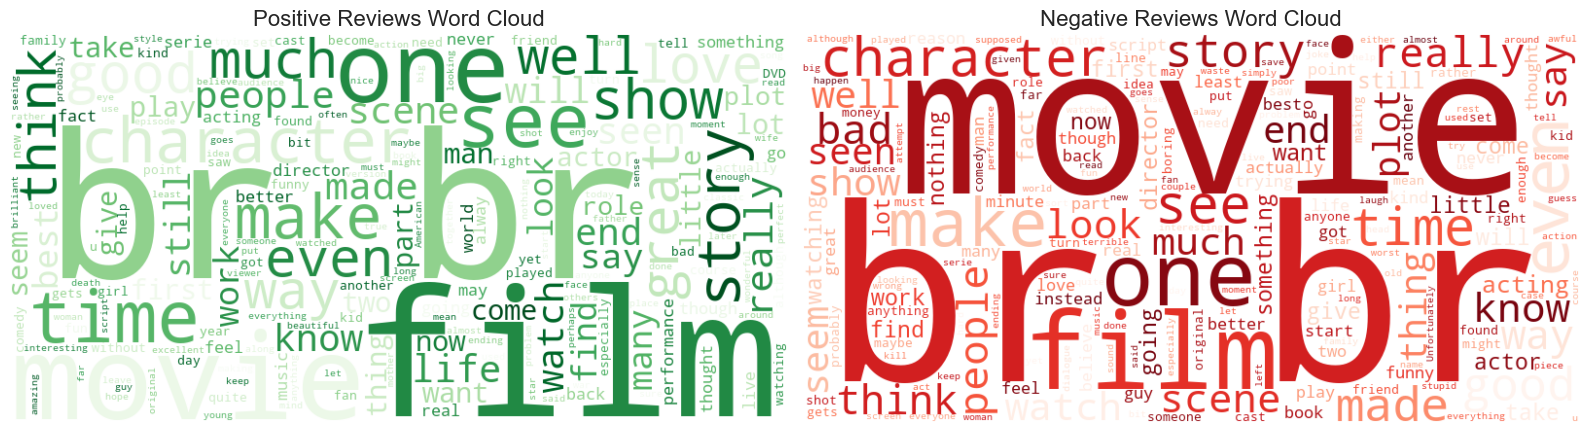

In [38]:
# Separate positive and negative reviews
positive_reviews = ' '.join(df[df['sentiment']=='positive']['review'])
negative_reviews = ' '.join(df[df['sentiment']=='negative']['review'])

# Generate word clouds
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_reviews)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_reviews)

# Display
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews Word Cloud', fontsize=16)

axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews Word Cloud', fontsize=16)

plt.tight_layout()
plt.show()

In [39]:
# Save positive word cloud
plt.figure(1)
plt.savefig('../reports/wordcloud_pos.png', dpi=300, bbox_inches='tight')

# Save negative word cloud
plt.figure(2)
plt.savefig('../reports/wordcloud_neg.png', dpi=300, bbox_inches='tight')

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

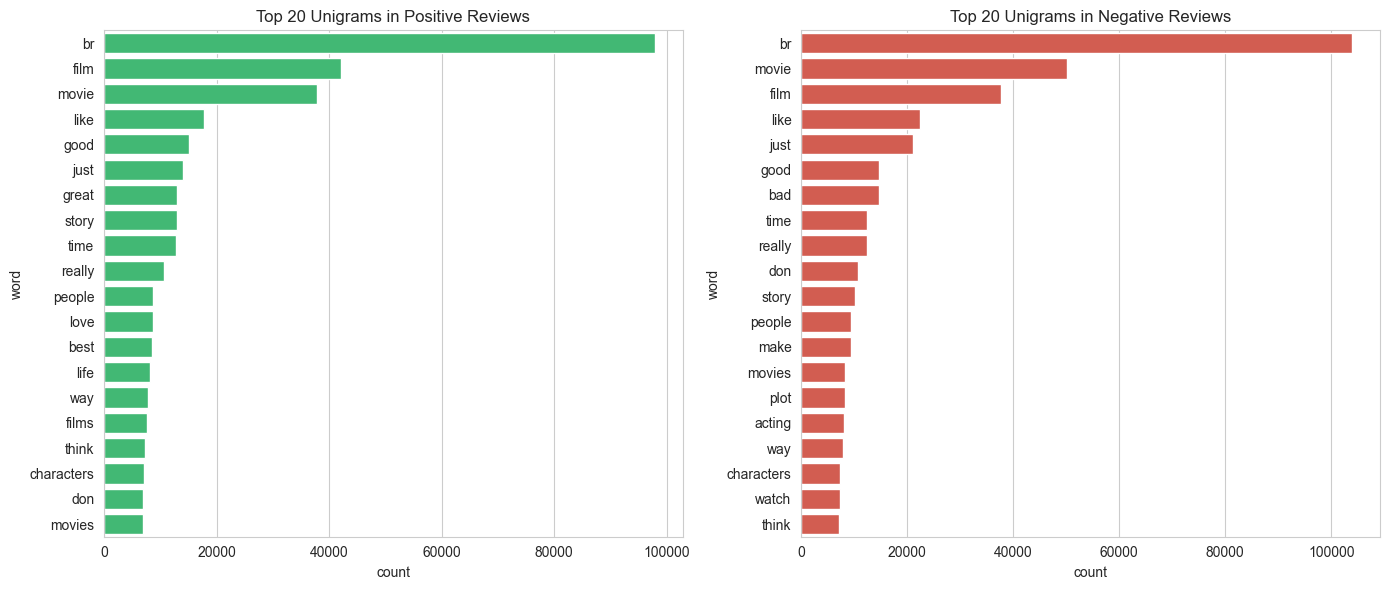

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

# Function to get top n-grams
def get_top_ngrams(corpus, n=None, ngram_range=(1,1), stop_words='english'):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=stop_words, max_features=20).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Positive top unigrams
pos_words = get_top_ngrams(df[df['sentiment']=='positive']['review'], n=20, ngram_range=(1,1))
pos_df = pd.DataFrame(pos_words, columns=['word', 'count'])

# Negative top unigrams
neg_words = get_top_ngrams(df[df['sentiment']=='negative']['review'], n=20, ngram_range=(1,1))
neg_df = pd.DataFrame(neg_words, columns=['word', 'count'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=pos_df, x='count', y='word', ax=axes[0], color='#2ecc71')
axes[0].set_title('Top 20 Unigrams in Positive Reviews')

sns.barplot(data=neg_df, x='count', y='word', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 20 Unigrams in Negative Reviews')

plt.tight_layout()
plt.show()

In [41]:
plt.savefig('../reports/top_unigrams.png', dpi=300, bbox_inches='tight')

<Figure size 1200x600 with 0 Axes>

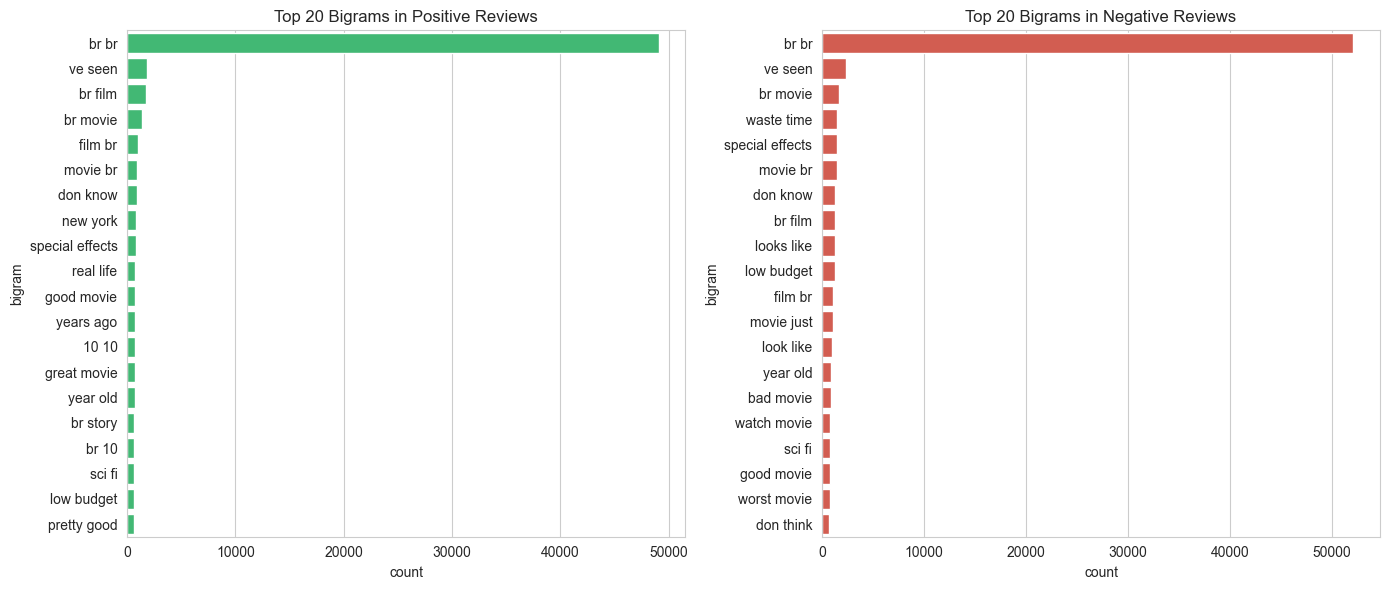

In [42]:
# Positive bigrams
pos_bigrams = get_top_ngrams(df[df['sentiment']=='positive']['review'], n=20, ngram_range=(2,2))
pos_bigram_df = pd.DataFrame(pos_bigrams, columns=['bigram', 'count'])

# Negative bigrams
neg_bigrams = get_top_ngrams(df[df['sentiment']=='negative']['review'], n=20, ngram_range=(2,2))
neg_bigram_df = pd.DataFrame(neg_bigrams, columns=['bigram', 'count'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=pos_bigram_df, x='count', y='bigram', ax=axes[0], color='#2ecc71')
axes[0].set_title('Top 20 Bigrams in Positive Reviews')

sns.barplot(data=neg_bigram_df, x='count', y='bigram', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 20 Bigrams in Negative Reviews')

plt.tight_layout()
plt.show()

In [47]:
plt.savefig('../reports/top_unigrams.png', dpi=300, bbox_inches='tight')

<Figure size 1200x600 with 0 Axes>

In [48]:
plt.savefig('../reports/top_bigrams.png', dpi=300, bbox_inches='tight')

<Figure size 1200x600 with 0 Axes>

In [49]:
# Summary of findings
print("EDA Summary:")
print("- Dataset is balanced: {} positive, {} negative".format(sentiment_counts['positive'], sentiment_counts['negative']))
print("- Average review length: {:.0f} characters, {:.0f} words".format(df['review_length'].mean(), df['word_count'].mean()))
print("- There are no missing values.")
print("- Word clouds show expected sentiment words (e.g., 'great', 'good' in positive; 'bad', 'worst' in negative).")

# Save a cleaned version if needed (optional)
# df.to_csv('../data/processed/cleaned_reviews.csv', index=False)

print("\nNext step: Preprocessing and feature engineering (02_preprocessing.ipynb)")

EDA Summary:
- Dataset is balanced: 25000 positive, 25000 negative
- Average review length: 1309 characters, 231 words
- There are no missing values.
- Word clouds show expected sentiment words (e.g., 'great', 'good' in positive; 'bad', 'worst' in negative).

Next step: Preprocessing and feature engineering (02_preprocessing.ipynb)


Libraries imported successfully!
Dataset shape: (50000, 2)

First 5 rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing values per column:
review       0
sentiment    0
dtype: int64
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


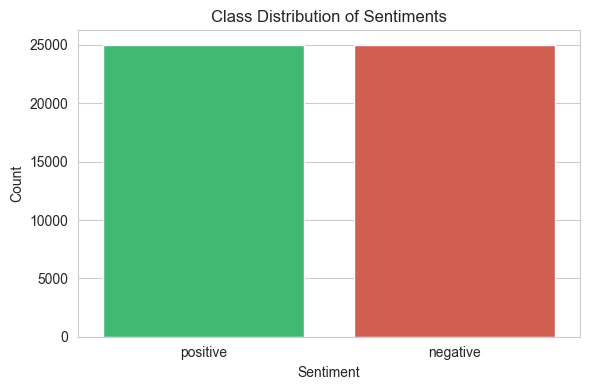

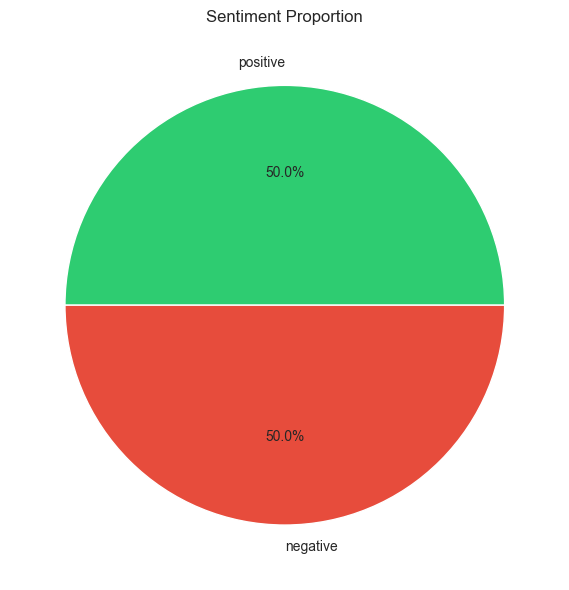

Review length (characters):
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

Word count:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


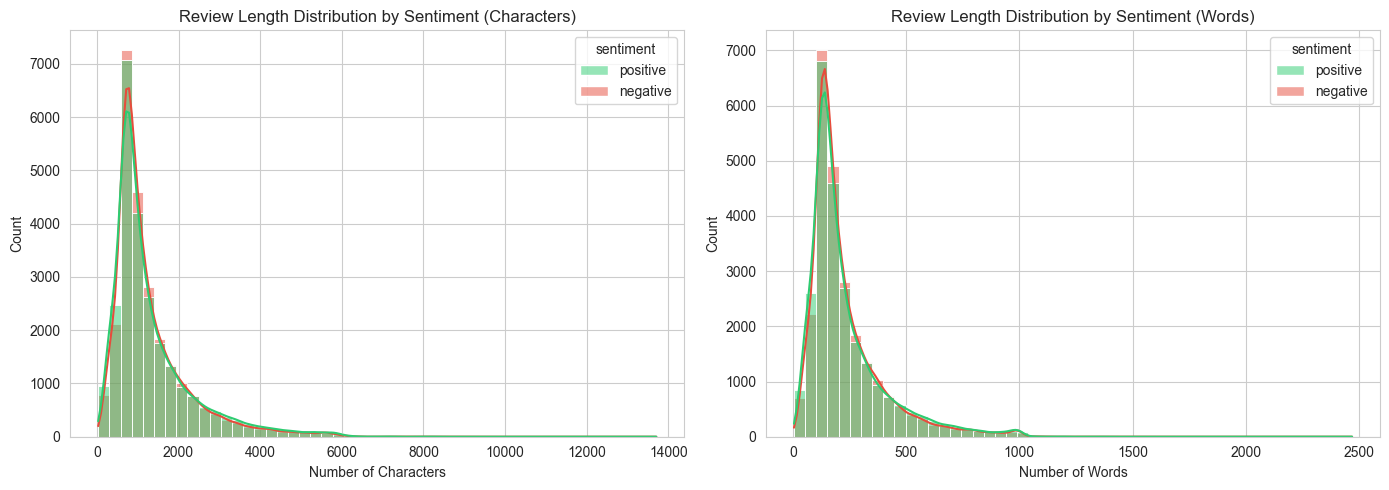

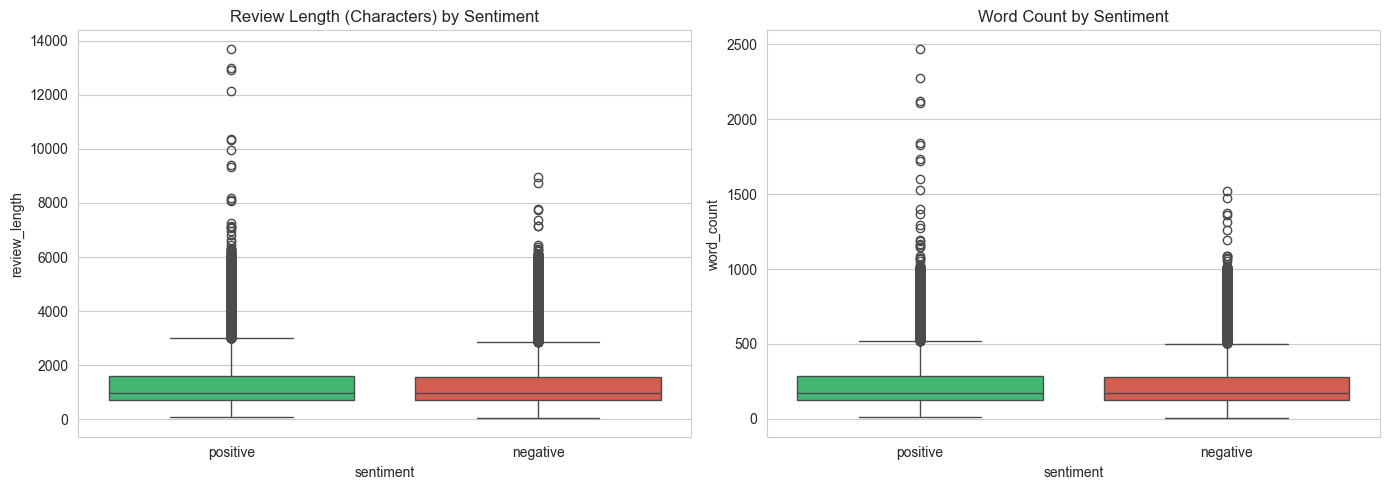

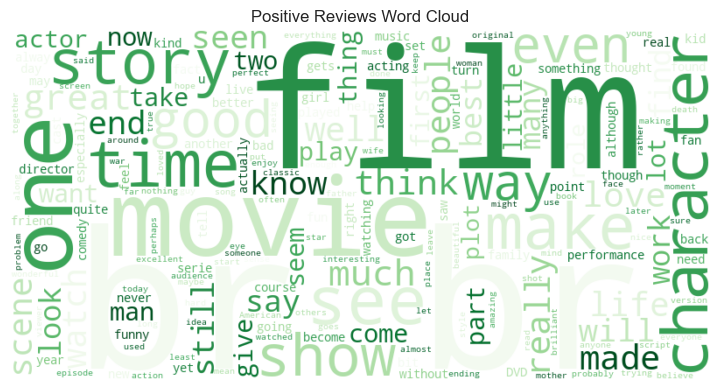

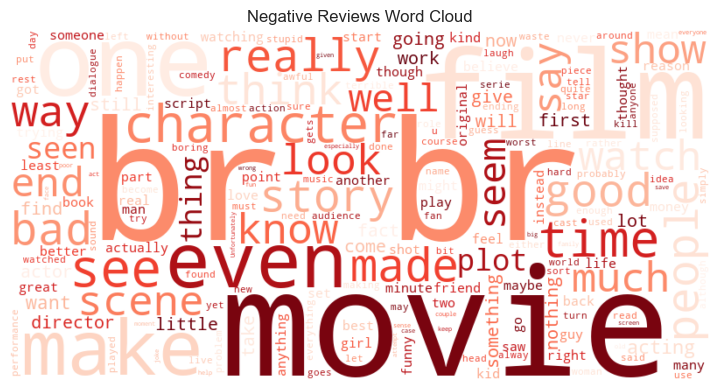

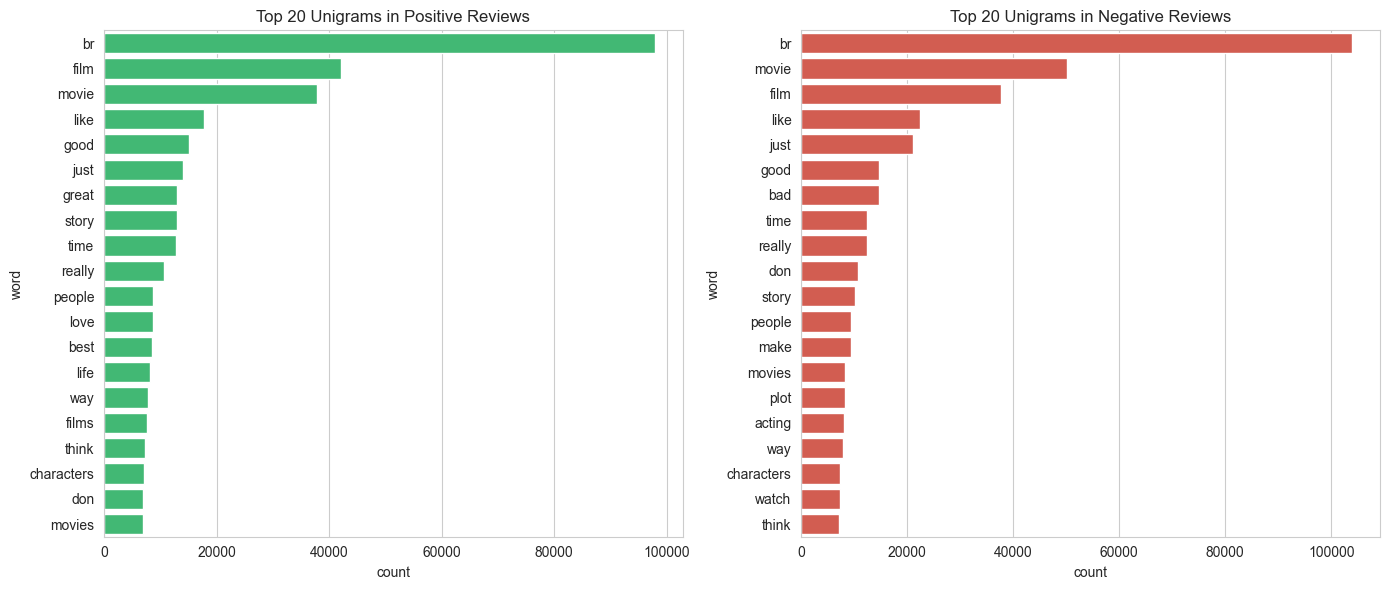

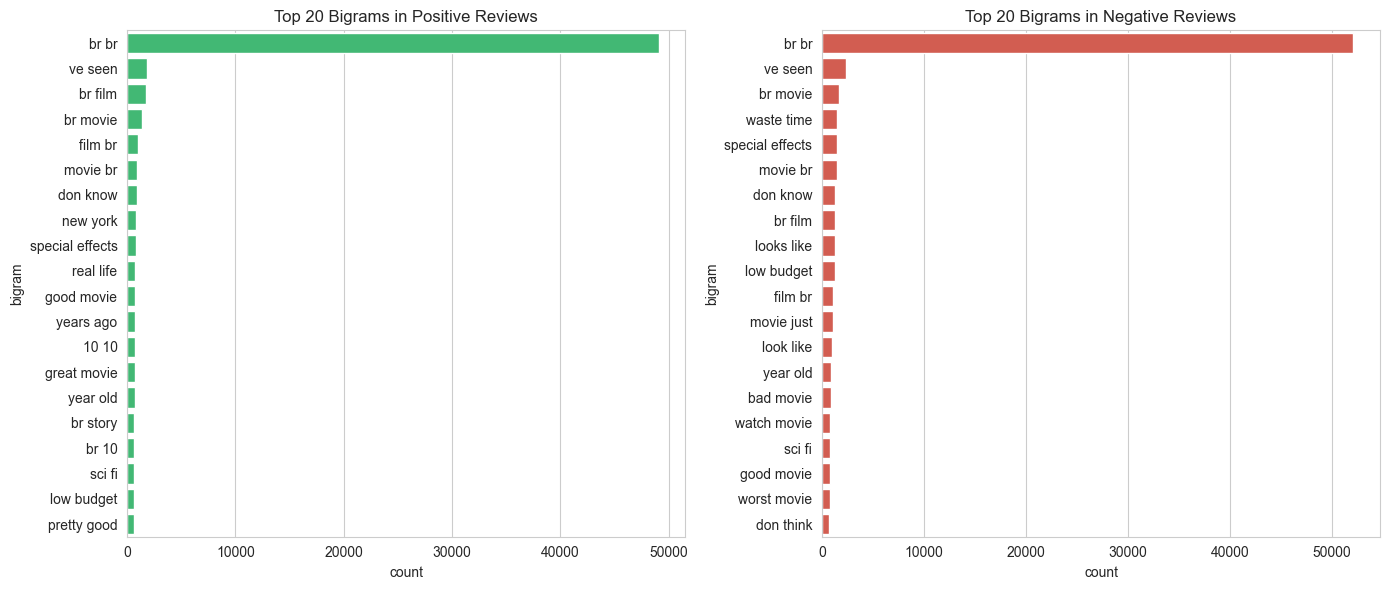


EDA Summary:
- Dataset is balanced: 25000 positive, 25000 negative
- Average review length: 1309 characters, 231 words
- There are no missing values.
- Word clouds show expected sentiment words (e.g., 'great', 'good' in positive; 'bad', 'worst' in negative).

Next step: Preprocessing and feature engineering (02_preprocessing.ipynb)


In [50]:
# 01_eda.ipynb - Corrected version with proper image saving

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

# Load the dataset
df = pd.read_csv('../data/raw/IMDB Dataset.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

# Check column names, data types, missing values
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

# Check the distribution of sentiments
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

# Visualize class distribution with bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
plt.title('Sentiment Proportion')
plt.tight_layout()
plt.savefig('../reports/class_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

# Add columns for review length and word count
df['review_length'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

# Summary statistics
print("Review length (characters):")
print(df['review_length'].describe())
print("\nWord count:")
print(df['word_count'].describe())

# Histograms for review length by sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='review_length', hue='sentiment', bins=50, kde=True, ax=axes[0],
             palette={'positive':'#2ecc71', 'negative':'#e74c3c'})
axes[0].set_title('Review Length Distribution by Sentiment (Characters)')
axes[0].set_xlabel('Number of Characters')

sns.histplot(data=df, x='word_count', hue='sentiment', bins=50, kde=True, ax=axes[1],
             palette={'positive':'#2ecc71', 'negative':'#e74c3c'})
axes[1].set_title('Review Length Distribution by Sentiment (Words)')
axes[1].set_xlabel('Number of Words')

plt.tight_layout()
plt.savefig('../reports/review_length_dist.png', dpi=300, bbox_inches='tight')
plt.show()

# Boxplots to see outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='sentiment', y='review_length', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Review Length (Characters) by Sentiment')

sns.boxplot(data=df, x='sentiment', y='word_count', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Word Count by Sentiment')

plt.tight_layout()
plt.savefig('../reports/boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# Generate word clouds for positive and negative reviews
positive_reviews = ' '.join(df[df['sentiment']=='positive']['review'])
negative_reviews = ' '.join(df[df['sentiment']=='negative']['review'])

wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_reviews)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_reviews)

# Display and save positive word cloud
plt.figure(figsize=(8,4))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews Word Cloud')
plt.tight_layout()
plt.savefig('../reports/wordcloud_pos.png', dpi=300, bbox_inches='tight')
plt.show()

# Display and save negative word cloud
plt.figure(figsize=(8,4))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews Word Cloud')
plt.tight_layout()
plt.savefig('../reports/wordcloud_neg.png', dpi=300, bbox_inches='tight')
plt.show()

# Function to get top n-grams
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=None, ngram_range=(1,1), stop_words='english'):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=stop_words, max_features=20).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Positive top unigrams
pos_words = get_top_ngrams(df[df['sentiment']=='positive']['review'], n=20, ngram_range=(1,1))
pos_df = pd.DataFrame(pos_words, columns=['word', 'count'])

# Negative top unigrams
neg_words = get_top_ngrams(df[df['sentiment']=='negative']['review'], n=20, ngram_range=(1,1))
neg_df = pd.DataFrame(neg_words, columns=['word', 'count'])

# Plot and save top unigrams
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=pos_df, x='count', y='word', ax=axes[0], color='#2ecc71')
axes[0].set_title('Top 20 Unigrams in Positive Reviews')
sns.barplot(data=neg_df, x='count', y='word', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 20 Unigrams in Negative Reviews')
plt.tight_layout()
plt.savefig('../reports/top_unigrams.png', dpi=300, bbox_inches='tight')
plt.show()

# Positive bigrams
pos_bigrams = get_top_ngrams(df[df['sentiment']=='positive']['review'], n=20, ngram_range=(2,2))
pos_bigram_df = pd.DataFrame(pos_bigrams, columns=['bigram', 'count'])

# Negative bigrams
neg_bigrams = get_top_ngrams(df[df['sentiment']=='negative']['review'], n=20, ngram_range=(2,2))
neg_bigram_df = pd.DataFrame(neg_bigrams, columns=['bigram', 'count'])

# Plot and save top bigrams
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=pos_bigram_df, x='count', y='bigram', ax=axes[0], color='#2ecc71')
axes[0].set_title('Top 20 Bigrams in Positive Reviews')
sns.barplot(data=neg_bigram_df, x='count', y='bigram', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 20 Bigrams in Negative Reviews')
plt.tight_layout()
plt.savefig('../reports/top_bigrams.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary of findings
print("\nEDA Summary:")
print(f"- Dataset is balanced: {sentiment_counts['positive']} positive, {sentiment_counts['negative']} negative")
print(f"- Average review length: {df['review_length'].mean():.0f} characters, {df['word_count'].mean():.0f} words")
print("- There are no missing values.")
print("- Word clouds show expected sentiment words (e.g., 'great', 'good' in positive; 'bad', 'worst' in negative).")
print("\nNext step: Preprocessing and feature engineering (02_preprocessing.ipynb)")